In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
from bluesky.utils import install_nb_kicker
install_nb_kicker()

In [3]:
# startup.py
from collections import defaultdict

# Standard Bluesky imports
from bluesky.plans import *
from bluesky.plan_stubs import *
from bluesky import RunEngine
from bluesky.utils import short_uid
from bluesky.callbacks import LiveTable, LivePlot
from bluesky.callbacks.broker import LiveImage
from bluesky.callbacks.best_effort import BestEffortCallback

#from config.detectors import eiger
#from config.detectors import *
from config.counters import *
from config.motors import *
from config.runengine import setup_runengine_with_databroker

#from plans.scan_functions import run_burst_scan
from plans.alignment import scan_monitor_vs_motor
from plans.alignment_modular import (
    run_monitor_scan, fit_data, plot_fit, move_to_statistic, save_alignment_metadata
)

from utils.plot_tools import plot_multiple_signals, interactive_signal_plot
#from utils.eiger_roi_gui import create_eiger_roi_gui, LiveRoiStatsPlot
#from utils.eiger_funcs import *

from bluesky.magics import BlueskyMagics
get_ipython().register_magics(BlueskyMagics)

Motor sx initialized successfully.
Motor th initialized successfully.
Motor sfpx initialized successfully.


In [4]:
#wa

In [5]:
RE, catalog = setup_runengine_with_databroker()
# bec = BestEffortCallback()
# RE.subscribe(bec)

# #BlueskyMagics.detectors = [eiger, counters]
# # BlueskyMagics.positioners = motor_list

# get_eiger_config(eiger)

Scheduled retry in 0.78 seconds due to ConnectError('[Errno 111] Connection refused') (attempt 1)
Scheduled retry in 0.81 seconds due to ConnectError('[Errno 111] Connection refused') (attempt 2)
Scheduled retry in 0.52 seconds due to ConnectError('[Errno 111] Connection refused') (attempt 3)
Scheduled retry in 1.2 seconds due to ConnectError('[Errno 111] Connection refused') (attempt 4)
Scheduled retry in 2.5 seconds due to ConnectError('[Errno 111] Connection refused') (attempt 5)
Scheduled retry in 3.5 seconds due to ConnectError('[Errno 111] Connection refused') (attempt 6)
Scheduled retry in 5.0 seconds due to ConnectError('[Errno 111] Connection refused') (attempt 7)
Scheduled retry in 5.0 seconds due to ConnectError('[Errno 111] Connection refused') (attempt 8)
Scheduled retry in 5.0 seconds due to ConnectError('[Errno 111] Connection refused') (attempt 9)


⚠️ Could not connect to Tiled server: [Errno 111] Connection refused


RuntimeError: No working data catalog could be established. Tiled server must be running.

In [6]:
# integrated_detector.py
import time
import threading
from ophyd import Device, Component as Cpt, Signal, EpicsSignalRO, DeviceStatus

class IntegratedAnalog(Device):
    """
    Integrate an analog PV for 'integration_time' seconds
    and expose the sum as the detector's datum.
    """
    val = Cpt(EpicsSignalRO, '')  # Analog input PV

    integration_time = Cpt(Signal, value=1.0, kind='config')   # Integration window [s]
    sample_dt        = Cpt(Signal, value=0.01, kind='config')  # Sample interval [s]
    integrated       = Cpt(Signal, value=0.0)   # Integrated result

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.integrated.name = self.name 
        
    def trigger(self):
        status = DeviceStatus(self)

        def _acq():
            try:
                t_total = float(self.integration_time.get())
                dt = float(self.sample_dt.get())
            except Exception as e:
                print(f"[{self.name}] Error reading integration settings: {e}")
                status._finished(success=False)
                return

            start = time.time()
            acc = 0.0
            n_samples = 0

            try:
                while time.time() - start < t_total:
                    try:
                        value = float(self.val.get())
                    except Exception as e:
                        print(f"[{self.name}] Failed to read PV: {e}")
                        value = 0.0  # Optionally skip or abort here
                    acc += value * dt
                    n_samples += 1
                    time.sleep(dt)
                self.integrated.put(acc)
                # print(f"[{self.name}] Integrated over {n_samples} samples, result: {acc:.6f}")
                status._finished(success=True)
            except Exception as e:
                print(f"[{self.name}] Unexpected error during integration: {e}")
                status._finished(success=False)

        threading.Thread(target=_acq, daemon=True).start()
        return status

    def read(self):
        try:
            return {
                self.name: {
                    'value': self.integrated.get(),
                    'timestamp': time.time()
                }
            }
        except Exception as e:
            print(f"[{self.name}] Error reading integrated value: {e}")
            return {
                self.name: {
                    'value': float('nan'),
                    'timestamp': time.time()
                }
            }

    def describe(self):
        return {
            self.name: {
                'dtype': 'number',
                'shape': [],
                'units': 'V·s',
                'source': 'calculated'
            }
        }


def init_integrated_counters(integration_time=1.0):
    i0 = IntegratedAnalog('BL17-2:RIO1:GalilAi0_MON.VAL', name='i0')
    i1 = IntegratedAnalog('BL17-2:RIO1:GalilAi1_MON.VAL', name='i1')
    i2 = IntegratedAnalog('BL17-2:RIO1:GalilAi2_MON.VAL', name='i2')
    bs = IntegratedAnalog('BL17-2:RIO1:GalilAi3_MON.VAL', name='bs')

    for det in [i0, i1, i2, bs]:
        det.integration_time.put(integration_time)
        det.read_attrs = ['integrated']
        det.integrated.kind = 'hinted'

    return i0, i1, i2, bs


# beamline_integrated_counters.py
# from integrated_detector import IntegratedAnalog

i0, i1, i2, bs = init_integrated_counters(integration_time=1.0)
counters = [i0, i1, i2, bs]


def set_count_time(integration_time):
    """
    Set the integration time for all counters.
    """
    for det in counters:
        det.integration_time.put(integration_time)
    
    print(f"Count time: {integration_time} seconds")

## Count Function

In [10]:
def cnt(time=1.0, num=1, delay=None):
    """
    Count global beamline counters with integrated readout using BestEffortCallback.

    Parameters
    ----------
    time : float
        Integration time in seconds (applied to all counters).
    num : int
        Number of repetitions.
    delay : float or None
        Delay between repetitions (seconds).
    
    Returns
    -------
    RunEngine status object
    """
    try:
        global counters
    except NameError as e:
        raise RuntimeError("One or more of the global counters (i0, i1, i2, bs) are not defined.") from e

    set_count_time(time)
    return RE(count(counters, num=num, delay=delay))


In [7]:
def cnt2():
    return RE(count(counters))
set_count_time(1)

Count time: 1 seconds


In [11]:
#pip install numpy time IPython matplotlib ipywidgets lmfit
import numpy as np
import time
import threading
from IPython import display as disp
from IPython.display import display
import matplotlib.pyplot as plt
import ipywidgets as widgets
from lmfit import Model
%matplotlib widget
PLOT_REFRESH_INTERVAL = .5 #not including data collection time + overhead
START_TIME = time.time()

In [ ]:
def gaussian(x, a=1, mu=0, sigma=1):
    """Gaussian function: y = a * exp(-(x-mu)^2 / (2*sigma^2))"""
    return a * np.exp(-((x - mu)**2) / (2 * sigma**2))

def lorentzian(x, a=1, x0=0, gamma=1):
    """Lorentzian function: y = a * gamma^2 / ((x-x0)^2 + gamma^2)"""
    return a * (gamma**2) / ((x - x0)**2 + gamma**2)

def pseudo_voigt(x, a=1, x0=0, sigma=1, gamma=1, eta=0.5):
    """Pseudo-Voigt function: linear combination of Gaussian and Lorentzian"""
    g = np.exp(-((x - x0)**2) / (2 * sigma**2))
    l = (gamma**2) / ((x - x0)**2 + gamma**2)
    return a * ((1 - eta) * g + eta * l)

def calculate_basic_stats(x, y):
    """Calculate basic statistics: peak, center, COM, AUC, FWHM"""
    x, y = np.array(x), np.array(y)
    sort_idx = np.argsort(x)
    x, y = x[sort_idx], y[sort_idx]
    
    peak = np.max(y)
    center = x[np.argmax(y)]
    com = np.sum(x * y) / np.sum(y) if np.sum(y) > 0 else center
    auc = np.trapezoid(y, x)
    #fwhm
    half_max = peak / 2
    indices = np.where(y >= half_max)[0]
    fwhm = float('nan') if len(indices) < 2 else x[indices[-1]] - x[indices[0]]
    
    return {
        'peak': peak,
        'center': center,
        'com': com,
        'auc': auc,
        'fwhm': fwhm
    }

def fit_curve(x, y, fit_type='Gaussian'):
    """Fit curve to data using specified fit type"""
    if len(x) < 10:
        return None, None, None, None
    
    x, y = np.array(x), np.array(y)
    sort_idx = np.argsort(x)
    x, y = x[sort_idx], y[sort_idx]
    
    peak = np.max(y)
    center = x[np.argmax(y)]
    sigma_est = (x[-1] - x[0]) / 10
    
    try:
        if fit_type == 'Gaussian':
            model = Model(gaussian)
            params = model.make_params(a=peak, mu=center, sigma=sigma_est)
        elif fit_type == 'Lorentzian':
            model = Model(lorentzian)
            params = model.make_params(a=peak, x0=center, gamma=sigma_est)
        elif fit_type == 'Pseudo-Voigt':
            model = Model(pseudo_voigt)
            params = model.make_params(a=peak, x0=center, sigma=sigma_est, gamma=sigma_est, eta=0.5)
            params['eta'].min, params['eta'].max = 0, 1
        
        fit_result = model.fit(y, params, x=x)
        
        x_fit = np.linspace(x.min(), x.max(), 500)
        y_fit = model.eval(fit_result.params, x=x_fit)
        
        y_fit_at_data_points = model.eval(fit_result.params, x=x)
        ss_res = np.sum((y - y_fit_at_data_points) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        
        return x_fit, y_fit, fit_result.best_values, r_squared
        
    except Exception:
        return None, None, None, None

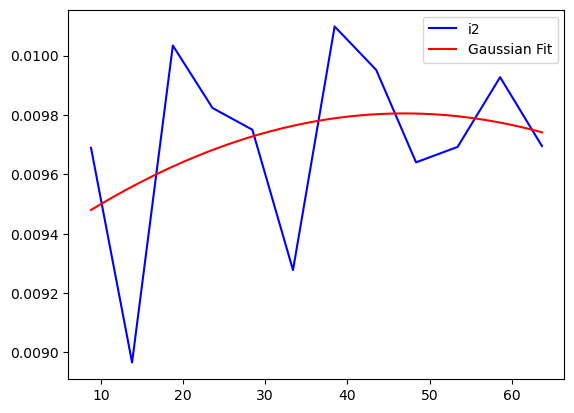

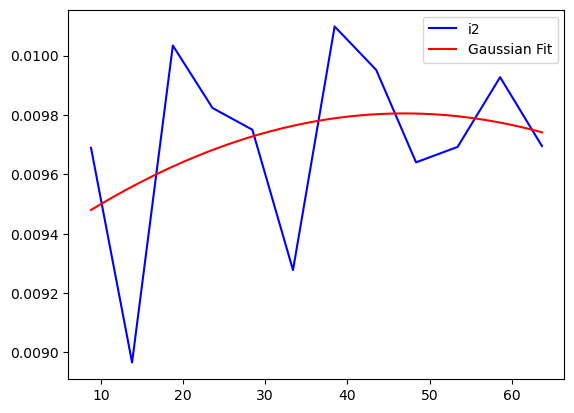

In [ ]:
stop_button = widgets.Button(
    description='End Plot',
    button_style='success',
    tooltip='Click to end plotting'
)

counter_dropdown = widgets.Dropdown(
    options=['i0', 'i1', 'i2', 'bs'],
    value='i0',
    description='Counter:'
)

fit_type_dropdown = widgets.Dropdown(
    options=['Gaussian', 'Lorentzian', 'Pseudo-Voigt'],
    value='Gaussian',
    description='Fit Type:'
)

toggle_fit_button = widgets.ToggleButton(
    value=True,
    description='Toggle Fit Line',
    button_style='info',
    tooltip='Show/hide curve fit on plot'
)

def get_fit_equation(fit_type):
    """Changes fit equation on stats tab"""
    equations = {
        'Gaussian': 'y = a × e^(−(x − μ)²/(2σ²))',
        'Lorentzian': 'y = a × γ²/((x − x₀)² + γ²)',
        'Pseudo-Voigt': 'y = a × [(1−η) × e^(−(x−x₀)²/(2σ²)) + η × γ²/((x−x₀)²+γ²)]'
    }
    return equations.get(fit_type, '')

def on_toggle_fit_changed(change):
    """Changes button color from blue to red when toggled"""
    if change['new']:
        toggle_fit_button.button_style = 'info'
    else:
        toggle_fit_button.button_style = 'danger'

toggle_fit_button.observe(on_toggle_fit_changed, names='value')

controls_row1 = widgets.HBox([stop_button, counter_dropdown])
controls_row2 = widgets.HBox([toggle_fit_button, fit_type_dropdown])
#tab1
controls_content = widgets.VBox([controls_row1, controls_row2])

# tab2
stats_title = widgets.HTML("<b>Statistics</b>")
peak_label = widgets.Label("Peak: --")
center_label = widgets.Label("Center: --")
com_label = widgets.Label("COM: --")
fwhm_label = widgets.Label("FWHM: --")
auc_label = widgets.Label("AUC: --")

stats_column = widgets.VBox([
    stats_title,
    peak_label,
    center_label,
    com_label,
    fwhm_label,
    auc_label
])

fit_params_title = widgets.HTML("<b>Fit Parameters</b>")
fit_params_labels = widgets.VBox([fit_params_title])

fit_params_column = widgets.VBox([fit_params_labels], layout=widgets.Layout(margin='0 0 0 50px'))

stats_content = widgets.HBox([stats_column, fit_params_column, fit_type_dropdown])

tabs = widgets.Tab([controls_content, stats_content])
tabs.titles = ['Controls', 'Stats']

output = widgets.Output()
stop_event = threading.Event()

def on_stop_button_clicked(b):
    """Ends plotting when clicked"""
    stop_event.set()
    with output:
        print(f"Ending Plotting")

stop_button.on_click(on_stop_button_clicked)

def plot_loop():
    """Main plot loop"""
    x = []
    data_streams = {
        'i0': [],
        'i1': [],
        'i2': [], 
        'bs': []
    }
    
    while not stop_event.is_set():
        x.append(time.time()-START_TIME)
        '''
        data_streams['i0'].append(np.sin(current_time))
        data_streams['i1'].append(np.cos(current_time))
        data_streams['i2'].append(np.sin(2*current_time))
        data_streams['bs'].append(np.sin(0.5*current_time) + 0.5)
        '''
        #not able to connect to test this
        status = i0.trigger()
        while not status.done:
            time.sleep(0.1)
        data_streams['i0'].append(i0.read()[i0.name]['value'])
        status = i1.trigger()
        while not status.done:
            time.sleep(0.1)
        data_streams['i1'].append(i1.read()[i1.name]['value'])
        status = i2.trigger()
        while not status.done:
            time.sleep(0.1)
        data_streams['i2'].append(i2.read()[i2.name]['value'])
        status = bs.trigger()
        while not status.done:
            time.sleep(0.1)
        data_streams['bs'].append(bs.read()[bs.name]['value'])


        plt.gca().cla()
        
        selected_counter = counter_dropdown.value
        selected_y_data = data_streams[selected_counter]
        
        plt.plot(x, selected_y_data, 'b-', label=selected_counter) 
        
        if len(x) > 3:
            stats = calculate_basic_stats(x, selected_y_data)
            if stats:
                peak_label.value = f"Peak: {stats['peak']:.3f}"
                center_label.value = f"Center: {stats['center']:.3f}"
                com_label.value = f"COM: {stats['com']:.3f}"
                fwhm_label.value = f"FWHM: {stats['fwhm']:.3f}"
                auc_label.value = f"AUC: {stats['auc']:.3f}"
        
        if toggle_fit_button.value and len(x) > 10:
            x_fit, y_fit, fit_params, r_squared = fit_curve(x, selected_y_data, fit_type_dropdown.value)
            if x_fit is not None and y_fit is not None:
                plt.plot(x_fit, y_fit, 'r-', label=f'{fit_type_dropdown.value} Fit')
                
                if fit_params:
                    param_widgets = [fit_params_title]
                    for param_name, param_value in fit_params.items():
                        param_widgets.append(widgets.Label(f"{param_name}: {param_value:.3f}"))
                    param_widgets.append(widgets.Label(f"R²: {r_squared:.3f}"))
                    param_widgets.append(widgets.HTML(f"<i>{get_fit_equation(fit_type_dropdown.value)}</i>"))
                    fit_params_labels.children = param_widgets
        else:
            fit_params_labels.children = [fit_params_title]
        
        plt.legend()
        disp.clear_output(wait=True)
        display(tabs)  
        display(plt.gcf()) 

        time.sleep(PLOT_REFRESH_INTERVAL)

thread = threading.Thread(target=plot_loop)
thread.start()




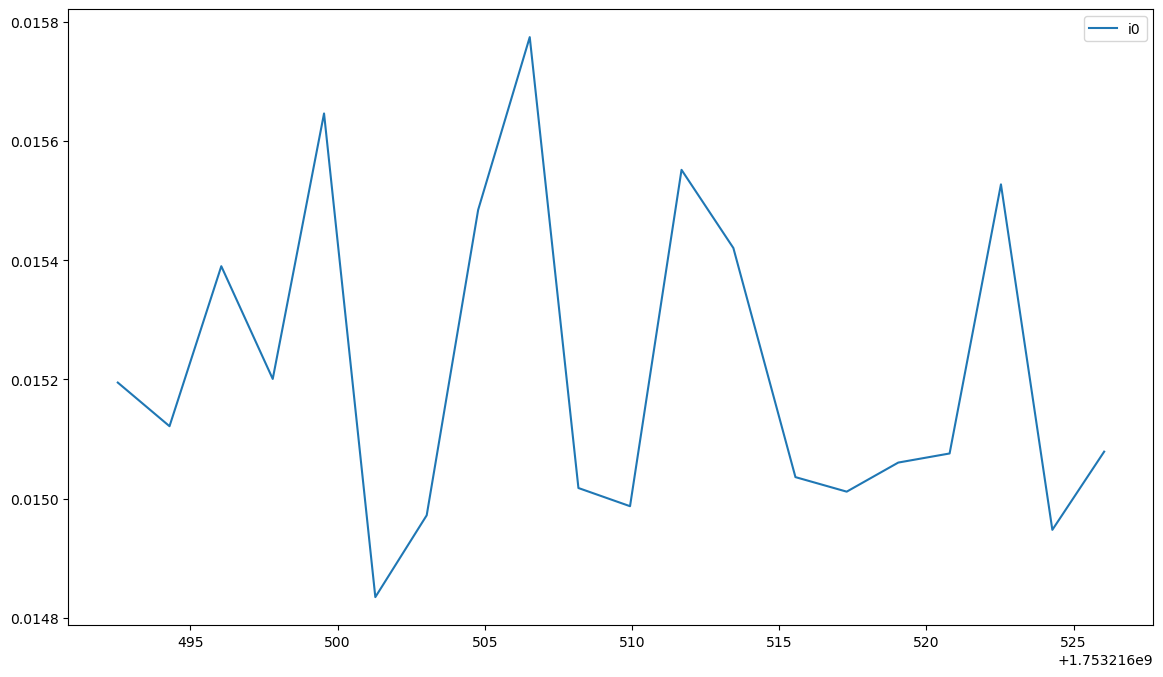

In [ ]:
#i0_reading = i0.read()
#i0_value = i0_reading['i0']['value']
#i0_value
# 
# 
import numpy as np
import time
from IPython import display

x = []
i0_data = []  
for i in range(20):
    
    status = i0.trigger()
    while not status.done:
        time.sleep(0.1)
    i0_val = i0.read()[i0.name]['value']
    i0_data = np.append(i0_data, i0_val)
    x = np.append(x, time.time())

    
    plt.gca().cla() 
    plt.plot(x, i0_data, label='i0') 
    plt.legend()
    display.clear_output(wait=True)
    display.display(plt.gcf()) 

    time.sleep(0.5) 

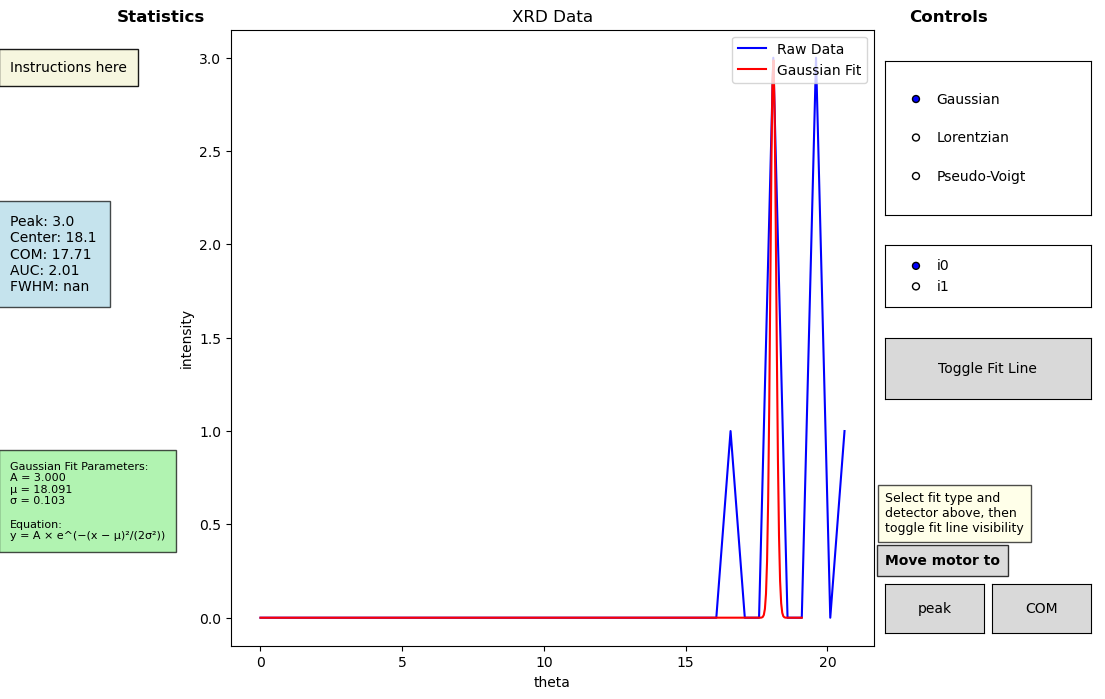

In [ ]:
%matplotlib inline
#pip install numpy matplotlib bluesky ophyd pyqt6 lmfit
from pathlib import Path
import time
from datetime import datetime
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.widgets import Button, RadioButtons
from lmfit import Model
from bluesky import RunEngine, Msg
from bluesky.callbacks import LivePlot
import bluesky.plan_stubs as bps
from ophyd.sim import SynSignal, SynAxis
from IPython.display import Image, display, clear_output

# Interval between stats panel refreshes in seconds
STATS_REFRESH_INTERVAL = 1
A, mu, sigma = 100, 50, 10  # Gaussian defaults

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)
print(f"Data directory created/confirmed: {DATA_DIR.absolute()}")

class OverlayedLivePlot(LivePlot):
    def __init__(self, y, x):
        self.y = y
        self.x = x
        self.text = None
        self.eq_text = None
        self.fit_line = None
        self.button = None
        self.radio = None
        self.dropdown = None
        self.fit_type = 'Gaussian'
        self.detector_type = 'i0'
        self.x_data = []
        self.y_data = []
        self.dummy_motor = SynAxis(name='dummy_motor')
        self.latest_com = None
        self.latest_center = None

        self.fig = plt.figure(figsize=(14, 8))
        gs = self.fig.add_gridspec(1, 3, width_ratios=[1, 3, 1], hspace=0.05, wspace=0.02)
        self.stats_ax = self.fig.add_subplot(gs[0, 0])
        self.stats_ax.set_xlim(0, 1)
        self.stats_ax.set_ylim(0, 1)
        self.stats_ax.axis('off')
        self.stats_ax.set_title('Statistics', fontsize=12, fontweight='bold', ha='left')
        self.ax = self.fig.add_subplot(gs[0, 1])
        self.controls_ax = self.fig.add_subplot(gs[0, 2])
        self.controls_ax.set_xlim(0, 1)
        self.controls_ax.set_ylim(0, 1)
        self.controls_ax.axis('off')
        self.controls_ax.set_title('Controls', fontsize=12, fontweight='bold', ha='right')
        self.ax.set_xlabel(x)
        self.ax.set_ylabel(y)
        self.ax.set_title('XRD Data')
        self.line = None

        self._setup_stats_panel()
        self._setup_controls_panel()

    def _setup_stats_panel(self):
        self.instructions_text = self.stats_ax.text(
            0.0, 0.95, "Instructions here",
            transform=self.stats_ax.transAxes, verticalalignment='top',
            horizontalalignment='left', fontsize=10, 
            bbox=dict(facecolor='beige', alpha=0.9, pad=8))

        self.stats_text = self.stats_ax.text(
            0.0, 0.7, 'Waiting for data...',
            transform=self.stats_ax.transAxes, verticalalignment='top',
            horizontalalignment='left', fontsize=10, 
            bbox=dict(facecolor='lightblue', alpha=0.7, pad=10))

        self.eq_text = self.stats_ax.text(
            0.0, 0.3, '', transform=self.stats_ax.transAxes,
            verticalalignment='top', horizontalalignment='left', fontsize=8,
            bbox=dict(facecolor='lightgreen', alpha=0.7, pad=8), wrap=True)

    def _setup_controls_panel(self):
        radio_ax = self.controls_ax.inset_axes([0.02, 0.7, 0.96, 0.25])
        self.radio = RadioButtons(radio_ax, ('Gaussian', 'Lorentzian', 'Pseudo-Voigt'), active=0)
        self.radio.on_clicked(self._on_fit_type_changed)

        dropdown_ax = self.controls_ax.inset_axes([0.02, 0.55, 0.96, 0.1])
        self.dropdown = RadioButtons(dropdown_ax, ('i0', 'i1'), active=0)
        self.dropdown.on_clicked(lambda label: setattr(self, 'detector_type', label))

        button_ax = self.controls_ax.inset_axes([0.02, 0.4, 0.96, 0.1])
        self.button = Button(button_ax, 'Toggle Fit Line')
        self.button.on_clicked(lambda e: self._toggle_fit_line())

        self.controls_ax.text(0.02, 0.25, 'Select fit type and\ndetector above, then\ntoggle fit line visibility',
                              transform=self.controls_ax.transAxes, verticalalignment='top',
                              horizontalalignment='left', fontsize=9, 
                              bbox=dict(facecolor='lightyellow', alpha=0.7, pad=5))

        self.controls_ax.text(0.02, 0.15, "Move motor to", transform=self.controls_ax.transAxes,
                              verticalalignment='top', horizontalalignment='left', fontsize=10, fontweight='bold',
                              bbox=dict(facecolor='lightgray', alpha=0.8, pad=6))

        move_peak_ax = self.controls_ax.inset_axes([0.02, 0.02, 0.46, 0.08])
        move_com_ax = self.controls_ax.inset_axes([0.52, 0.02, 0.46, 0.08])
        self.move_peak_btn = Button(move_peak_ax, "peak")
        self.move_com_btn = Button(move_com_ax, "COM")
        self.move_peak_btn.on_clicked(lambda e: self.dummy_motor.move(self.latest_center).wait() if self.latest_center is not None else print("Center position not available yet."))
        self.move_com_btn.on_clicked(lambda e: self.dummy_motor.move(self.latest_com).wait() if self.latest_com is not None else print("COM position not available yet."))

    def _on_fit_type_changed(self, label):
        self.fit_type = label
        if self.fit_line is not None:
            self.fit_line.set_label(f"{self.fit_type} Fit")
            self.fit_line.set_data([], [])
            self._update_legend()
        self.refit_current_data()

    def _toggle_fit_line(self):
        if self.fit_line is not None:
            visible = self.fit_line.get_visible()
            self.fit_line.set_visible(not visible)

    def update_stats(self, peak, center, fwhm, popt=None, com=None, auc=None):
        self.latest_com = com
        self.latest_center = center
        com_text = f"\nCOM: {com:.2f}" if com is not None else ""
        auc_text = f"\nAUC: {auc:.2f}" if auc is not None else ""
        stats_content = f"Peak: {peak:.1f}\nCenter: {center:.1f}{com_text}{auc_text}\nFWHM: {fwhm:.1f}"
        self.stats_text.set_text(stats_content)

        if popt is not None:
            labels = ['A', 'μ', 'σ'] if self.fit_type == 'Gaussian' else ['A', 'x₀', 'γ']
            if self.fit_type == 'Pseudo-Voigt':
                labels = ['A', 'x₀', 'σ', 'γ', 'η']
            param_str = "\n".join(f"{k} = {v:.3f}" for k, v in zip(labels, popt))
            if self.fit_type == 'Gaussian':
                eq_str = r"y = A × e^(−(x − μ)²/(2σ²))"
            elif self.fit_type == 'Lorentzian':
                eq_str = r"y = A × γ²/((x − x₀)² + γ²)"
            else:
                eq_str = r"y = A × [(1 − η) × e^(−(x − x₀)²/(2σ²)) + η × γ²/((x − x₀)² + γ²)]"
            full_eq_text = f"{self.fit_type} Fit Parameters:\n{param_str}\n\nEquation:\n{eq_str}"
            self.eq_text.set_text(full_eq_text)
        else:
            self.eq_text.set_text('')

    def __call__(self, name, doc):
        if name == 'event':
            if self.y in doc['data'] and self.x in doc['data']:
                y_val = doc['data'][self.y]
                x_val = doc['data'][self.x]
                if self.line is None:
                    self.line, = self.ax.plot([], [], 'b-', label='Raw Data')
                    self.fit_line, = self.ax.plot([], [], 'r-', label=f'{self.fit_type} Fit')
                    self._update_legend()
                x_data = list(self.line.get_xdata())
                y_data = list(self.line.get_ydata())
                x_data.append(x_val)
                y_data.append(y_val)
                self.line.set_data(x_data, y_data)
                self.ax.relim()
                self.ax.autoscale_view()
                
                # Update plot in real-time for notebook
                clear_output(wait=True)
                display(self.fig)

    def _update_legend(self):
        self.ax.legend(*self.ax.get_legend_handles_labels(), loc='upper right')

    def refit_current_data(self):
        if len(self.x_data) > 10 and len(self.x_data) == len(self.y_data):
            calculate_stats(self, self.x_data, self.y_data)

def gaussian(x, a=1, mu=0, sigma=1):
    return a * np.exp(-((x - mu)**2) / (2 * sigma**2))

def lorentzian(x, a=1, x0=0, gamma=1):
    return a * (gamma**2) / ((x - x0)**2 + gamma**2)

def pseudo_voigt(x, a=1, x0=0, sigma=1, gamma=1, eta=0.5):
    g = np.exp(-((x - x0)**2) / (2 * sigma**2))
    l = (gamma**2) / ((x - x0)**2 + gamma**2)
    return a * ((1 - eta) * g + eta * l)

def gaussian_data_generator():
    x_range = np.linspace(0, 100, 200)
    for x in x_range:
        dummy_signal = gaussian(x, A, mu, sigma)
        noisy_signal = np.random.poisson(dummy_signal)
        yield x, noisy_signal

def calculate_stats(plot, x, y):
    x, y = np.array(x), np.array(y)
    if len(x) < 10 or len(x) != len(y): return
    sort_idx = np.argsort(x)
    x, y = x[sort_idx], y[sort_idx]
    peak = np.max(y)
    center = x[np.argmax(y)]
    com = np.sum(x * y) / np.sum(y)
    auc = np.trapezoid(y, x)
    try:
        if plot.fit_type == 'Gaussian':
            model = Model(gaussian)
            params = model.make_params(a=peak, mu=center, sigma=sigma)
        elif plot.fit_type == 'Lorentzian':
            model = Model(lorentzian)
            params = model.make_params(a=peak, x0=center, gamma=sigma)
        elif plot.fit_type == 'Pseudo-Voigt':
            model = Model(pseudo_voigt)
            params = model.make_params(a=peak, x0=center, sigma=sigma, gamma=sigma, eta=0.5)
            params['eta'].min, params['eta'].max = 0, 1
        fit_result = model.fit(y, params, x=x)
        y_fit = model.eval(fit_result.params, x=np.linspace(x.min(), x.max(), 500))
        plot.fit_line.set_data(np.linspace(x.min(), x.max(), 500), y_fit)
        plot.ax.relim()
        plot.ax.autoscale_view()
        popt = list(fit_result.best_values.values())
    except Exception as e:
        print(f"Fit failed: {e}")
        popt = None
    half_max = peak / 2
    indices = np.where(y >= half_max)[0]
    fwhm = float('nan') if len(indices) < 2 else x[indices[-1]] - x[indices[0]]
    plot.update_stats(peak, center, fwhm, popt, com, auc)

def stream(plot):
    global last_analysis_time
    yield Msg('open_run')
    try:
        for x, y in data_gen:
            intensity_signal.put(y)
            theta_signal.put(x)
            x_vals.append(x)
            y_vals.append(y)
            plot.x_data = x_vals
            plot.y_data = y_vals
            yield Msg('create', name='primary')
            yield Msg('read', intensity_signal)
            yield Msg('read', theta_signal)
            yield Msg('save')
            if time.time() - last_analysis_time >= STATS_REFRESH_INTERVAL:
                calculate_stats(plot, x_vals, y_vals)
                last_analysis_time = time.time()
            yield from bps.sleep(0.05)
    finally:
        yield Msg('close_run')


# --- Execution setup ---
last_analysis_time = time.time()
x_vals, y_vals = [], []
data_gen = gaussian_data_generator()
intensity_signal = SynSignal(name='intensity', func=lambda: 0)
theta_signal = SynSignal(name='theta', func=lambda: 0)

plot = OverlayedLivePlot('intensity', 'theta')
RE = RunEngine({})
RE.subscribe(plot)

RE(stream(plot))

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
data_filename = DATA_DIR / f'xrd_raw_data_{timestamp}.csv'
plot_filename = DATA_DIR / f'xrd_plot_{timestamp}.png'

np.savetxt(data_filename, np.column_stack((x_vals, y_vals)), delimiter=',', header='theta,intensity', comments='')
print(f'Saved data to {data_filename}')

plot.fig.savefig(plot_filename, dpi=150, bbox_inches='tight')
print(f'Saved plot to {plot_filename}')

plt.close(plot.fig)

In [ ]:
#1111111111111

Data directory created/confirmed: /home/b_thampy/bluesky_bl172/data


/tmp/ipykernel_1747117/1589624165.py:200: RuntimeWarning: invalid value encountered in scalar divide
  com = np.sum(x * y) / np.sum(y)


Saved data to data/xrd_raw_data_20250722_135515.csv
Saved plot to data/xrd_plot_20250722_135515.png


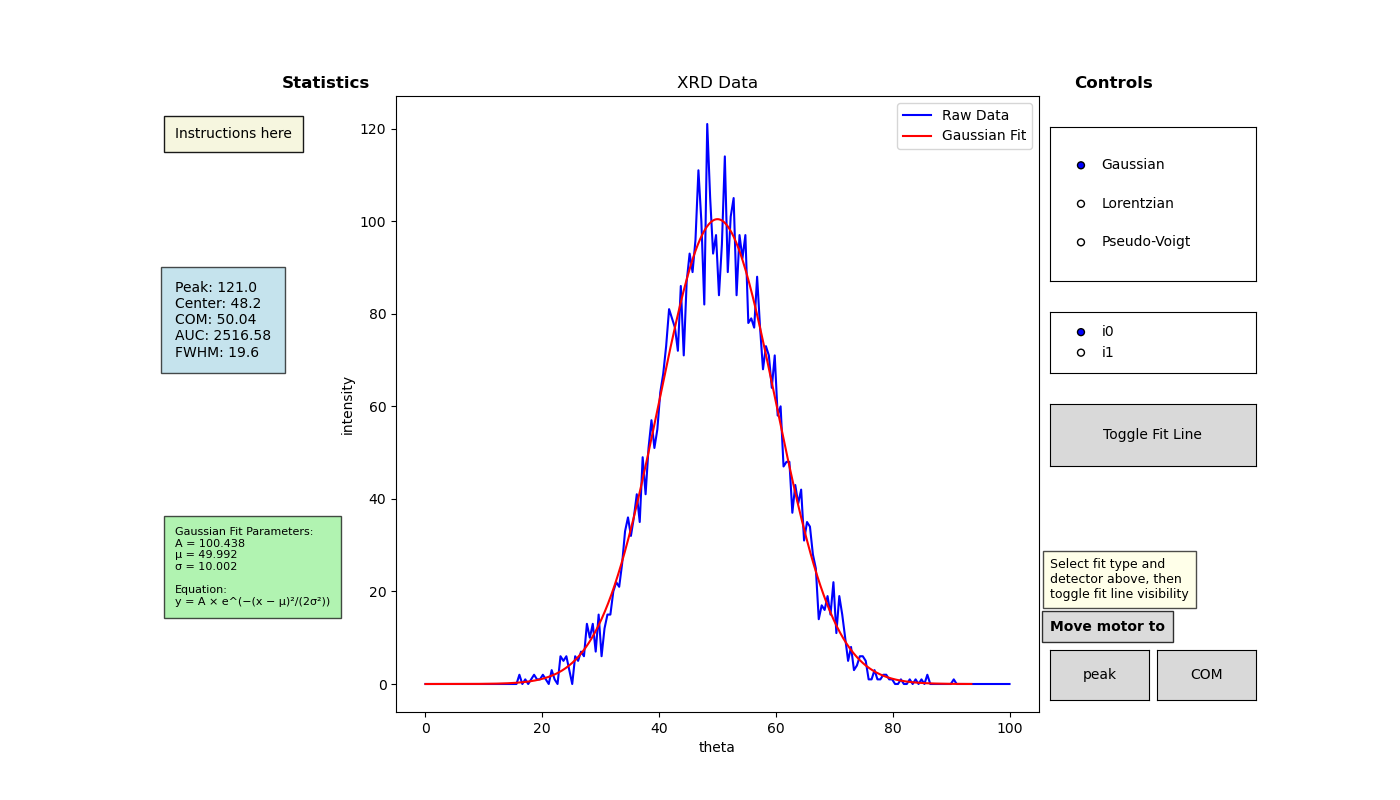

In [1]:
%matplotlib widget
#pip install numpy matplotlib bluesky ophyd pyqt6 lmfit ipympl
from pathlib import Path
import time
from datetime import datetime
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.widgets import Button, RadioButtons
from lmfit import Model
from bluesky import RunEngine, Msg
from bluesky.callbacks import LivePlot
import bluesky.plan_stubs as bps
from ophyd.sim import SynSignal, SynAxis
from IPython.display import Image, display, clear_output

# Interval between stats panel refreshes in seconds
STATS_REFRESH_INTERVAL = 1
A, mu, sigma = 100, 50, 10  # Gaussian defaults

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)
print(f"Data directory created/confirmed: {DATA_DIR.absolute()}")

class OverlayedLivePlot(LivePlot):
    def __init__(self, y, x):
        self.y = y
        self.x = x
        self.text = None
        self.eq_text = None
        self.fit_line = None
        self.button = None
        self.radio = None
        self.dropdown = None
        self.fit_type = 'Gaussian'
        self.detector_type = 'i0'
        self.x_data = []
        self.y_data = []
        self.dummy_motor = SynAxis(name='dummy_motor')
        self.latest_com = None
        self.latest_center = None

        self.fig = plt.figure(figsize=(14, 8))
        gs = self.fig.add_gridspec(1, 3, width_ratios=[1, 3, 1], hspace=0.05, wspace=0.02)
        self.stats_ax = self.fig.add_subplot(gs[0, 0])
        self.stats_ax.set_xlim(0, 1)
        self.stats_ax.set_ylim(0, 1)
        self.stats_ax.axis('off')
        self.stats_ax.set_title('Statistics', fontsize=12, fontweight='bold', ha='left')
        self.ax = self.fig.add_subplot(gs[0, 1])
        self.controls_ax = self.fig.add_subplot(gs[0, 2])
        self.controls_ax.set_xlim(0, 1)
        self.controls_ax.set_ylim(0, 1)
        self.controls_ax.axis('off')
        self.controls_ax.set_title('Controls', fontsize=12, fontweight='bold', ha='right')
        self.ax.set_xlabel(x)
        self.ax.set_ylabel(y)
        self.ax.set_title('XRD Data')
        self.line = None

        self._setup_stats_panel()
        self._setup_controls_panel()

    def _setup_stats_panel(self):
        self.instructions_text = self.stats_ax.text(
            0.0, 0.95, "Instructions here",
            transform=self.stats_ax.transAxes, verticalalignment='top',
            horizontalalignment='left', fontsize=10, 
            bbox=dict(facecolor='beige', alpha=0.9, pad=8))

        self.stats_text = self.stats_ax.text(
            0.0, 0.7, 'Waiting for data...',
            transform=self.stats_ax.transAxes, verticalalignment='top',
            horizontalalignment='left', fontsize=10, 
            bbox=dict(facecolor='lightblue', alpha=0.7, pad=10))

        self.eq_text = self.stats_ax.text(
            0.0, 0.3, '', transform=self.stats_ax.transAxes,
            verticalalignment='top', horizontalalignment='left', fontsize=8,
            bbox=dict(facecolor='lightgreen', alpha=0.7, pad=8), wrap=True)

    def _setup_controls_panel(self):
        radio_ax = self.controls_ax.inset_axes([0.02, 0.7, 0.96, 0.25])
        self.radio = RadioButtons(radio_ax, ('Gaussian', 'Lorentzian', 'Pseudo-Voigt'), active=0)
        self.radio.on_clicked(self._on_fit_type_changed)

        dropdown_ax = self.controls_ax.inset_axes([0.02, 0.55, 0.96, 0.1])
        self.dropdown = RadioButtons(dropdown_ax, ('i0', 'i1'), active=0)
        self.dropdown.on_clicked(lambda label: setattr(self, 'detector_type', label))

        button_ax = self.controls_ax.inset_axes([0.02, 0.4, 0.96, 0.1])
        self.button = Button(button_ax, 'Toggle Fit Line')
        self.button.on_clicked(lambda e: self._toggle_fit_line())

        self.controls_ax.text(0.02, 0.25, 'Select fit type and\ndetector above, then\ntoggle fit line visibility',
                              transform=self.controls_ax.transAxes, verticalalignment='top',
                              horizontalalignment='left', fontsize=9, 
                              bbox=dict(facecolor='lightyellow', alpha=0.7, pad=5))

        self.controls_ax.text(0.02, 0.15, "Move motor to", transform=self.controls_ax.transAxes,
                              verticalalignment='top', horizontalalignment='left', fontsize=10, fontweight='bold',
                              bbox=dict(facecolor='lightgray', alpha=0.8, pad=6))

        move_peak_ax = self.controls_ax.inset_axes([0.02, 0.02, 0.46, 0.08])
        move_com_ax = self.controls_ax.inset_axes([0.52, 0.02, 0.46, 0.08])
        self.move_peak_btn = Button(move_peak_ax, "peak")
        self.move_com_btn = Button(move_com_ax, "COM")
        self.move_peak_btn.on_clicked(lambda e: self.dummy_motor.move(self.latest_center).wait() if self.latest_center is not None else print("Center position not available yet."))
        self.move_com_btn.on_clicked(lambda e: self.dummy_motor.move(self.latest_com).wait() if self.latest_com is not None else print("COM position not available yet."))

    def _on_fit_type_changed(self, label):
        self.fit_type = label
        if self.fit_line is not None:
            self.fit_line.set_label(f"{self.fit_type} Fit")
            self.fit_line.set_data([], [])
            self._update_legend()
            self.fig.canvas.draw_idle()
        self.refit_current_data()

    def _toggle_fit_line(self):
        if self.fit_line is not None:
            visible = self.fit_line.get_visible()
            self.fit_line.set_visible(not visible)
            self.fig.canvas.draw_idle()

    def update_stats(self, peak, center, fwhm, popt=None, com=None, auc=None):
        self.latest_com = com
        self.latest_center = center
        com_text = f"\nCOM: {com:.2f}" if com is not None else ""
        auc_text = f"\nAUC: {auc:.2f}" if auc is not None else ""
        stats_content = f"Peak: {peak:.1f}\nCenter: {center:.1f}{com_text}{auc_text}\nFWHM: {fwhm:.1f}"
        self.stats_text.set_text(stats_content)

        if popt is not None:
            labels = ['A', 'μ', 'σ'] if self.fit_type == 'Gaussian' else ['A', 'x₀', 'γ']
            if self.fit_type == 'Pseudo-Voigt':
                labels = ['A', 'x₀', 'σ', 'γ', 'η']
            param_str = "\n".join(f"{k} = {v:.3f}" for k, v in zip(labels, popt))
            if self.fit_type == 'Gaussian':
                eq_str = r"y = A × e^(−(x − μ)²/(2σ²))"
            elif self.fit_type == 'Lorentzian':
                eq_str = r"y = A × γ²/((x − x₀)² + γ²)"
            else:
                eq_str = r"y = A × [(1 − η) × e^(−(x − x₀)²/(2σ²)) + η × γ²/((x − x₀)² + γ²)]"
            full_eq_text = f"{self.fit_type} Fit Parameters:\n{param_str}\n\nEquation:\n{eq_str}"
            self.eq_text.set_text(full_eq_text)
        else:
            self.eq_text.set_text('')

    def __call__(self, name, doc):
        if name == 'event':
            if self.y in doc['data'] and self.x in doc['data']:
                y_val = doc['data'][self.y]
                x_val = doc['data'][self.x]
                if self.line is None:
                    self.line, = self.ax.plot([], [], 'b-', label='Raw Data')
                    self.fit_line, = self.ax.plot([], [], 'r-', label=f'{self.fit_type} Fit')
                    self._update_legend()
                x_data = list(self.line.get_xdata())
                y_data = list(self.line.get_ydata())
                x_data.append(x_val)
                y_data.append(y_val)
                self.line.set_data(x_data, y_data)
                self.ax.relim()
                self.ax.autoscale_view()
                self.fig.canvas.draw_idle()

    def _update_legend(self):
        self.ax.legend(*self.ax.get_legend_handles_labels(), loc='upper right')

    def refit_current_data(self):
        if len(self.x_data) > 10 and len(self.x_data) == len(self.y_data):
            calculate_stats(self, self.x_data, self.y_data)

def gaussian(x, a=1, mu=0, sigma=1):
    return a * np.exp(-((x - mu)**2) / (2 * sigma**2))

def lorentzian(x, a=1, x0=0, gamma=1):
    return a * (gamma**2) / ((x - x0)**2 + gamma**2)

def pseudo_voigt(x, a=1, x0=0, sigma=1, gamma=1, eta=0.5):
    g = np.exp(-((x - x0)**2) / (2 * sigma**2))
    l = (gamma**2) / ((x - x0)**2 + gamma**2)
    return a * ((1 - eta) * g + eta * l)

def gaussian_data_generator():
    x_range = np.linspace(0, 100, 200)
    for x in x_range:
        dummy_signal = gaussian(x, A, mu, sigma)
        noisy_signal = np.random.poisson(dummy_signal)
        yield x, noisy_signal

def calculate_stats(plot, x, y):
    x, y = np.array(x), np.array(y)
    if len(x) < 10 or len(x) != len(y): return
    sort_idx = np.argsort(x)
    x, y = x[sort_idx], y[sort_idx]
    peak = np.max(y)
    center = x[np.argmax(y)]
    com = np.sum(x * y) / np.sum(y)
    auc = np.trapezoid(y, x)
    try:
        if plot.fit_type == 'Gaussian':
            model = Model(gaussian)
            params = model.make_params(a=peak, mu=center, sigma=sigma)
        elif plot.fit_type == 'Lorentzian':
            model = Model(lorentzian)
            params = model.make_params(a=peak, x0=center, gamma=sigma)
        elif plot.fit_type == 'Pseudo-Voigt':
            model = Model(pseudo_voigt)
            params = model.make_params(a=peak, x0=center, sigma=sigma, gamma=sigma, eta=0.5)
            params['eta'].min, params['eta'].max = 0, 1
        fit_result = model.fit(y, params, x=x)
        y_fit = model.eval(fit_result.params, x=np.linspace(x.min(), x.max(), 500))
        plot.fit_line.set_data(np.linspace(x.min(), x.max(), 500), y_fit)
        plot.ax.relim()
        plot.ax.autoscale_view()
        popt = list(fit_result.best_values.values())
    except Exception as e:
        print(f"Fit failed: {e}")
        popt = None
    half_max = peak / 2
    indices = np.where(y >= half_max)[0]
    fwhm = float('nan') if len(indices) < 2 else x[indices[-1]] - x[indices[0]]
    plot.update_stats(peak, center, fwhm, popt, com, auc)

def stream(plot):
    global last_analysis_time
    yield Msg('open_run')
    try:
        for x, y in data_gen:
            intensity_signal.put(y)
            theta_signal.put(x)
            x_vals.append(x)
            y_vals.append(y)
            plot.x_data = x_vals
            plot.y_data = y_vals
            yield Msg('create', name='primary')
            yield Msg('read', intensity_signal)
            yield Msg('read', theta_signal)
            yield Msg('save')
            if time.time() - last_analysis_time >= STATS_REFRESH_INTERVAL:
                calculate_stats(plot, x_vals, y_vals)
                last_analysis_time = time.time()
            yield from bps.sleep(0.05)
    finally:
        yield Msg('close_run')


# --- Execution setup ---
last_analysis_time = time.time()
x_vals, y_vals = [], []
data_gen = gaussian_data_generator()
intensity_signal = SynSignal(name='intensity', func=lambda: 0)
theta_signal = SynSignal(name='theta', func=lambda: 0)

plot = OverlayedLivePlot('intensity', 'theta')
RE = RunEngine({})
RE.subscribe(plot)

RE(stream(plot))

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
data_filename = DATA_DIR / f'xrd_raw_data_{timestamp}.csv'
plot_filename = DATA_DIR / f'xrd_plot_{timestamp}.png'

np.savetxt(data_filename, np.column_stack((x_vals, y_vals)), delimiter=',', header='theta,intensity', comments='')
print(f'Saved data to {data_filename}')

plot.fig.savefig(plot_filename, dpi=150, bbox_inches='tight')
print(f'Saved plot to {plot_filename}')

plt.show()

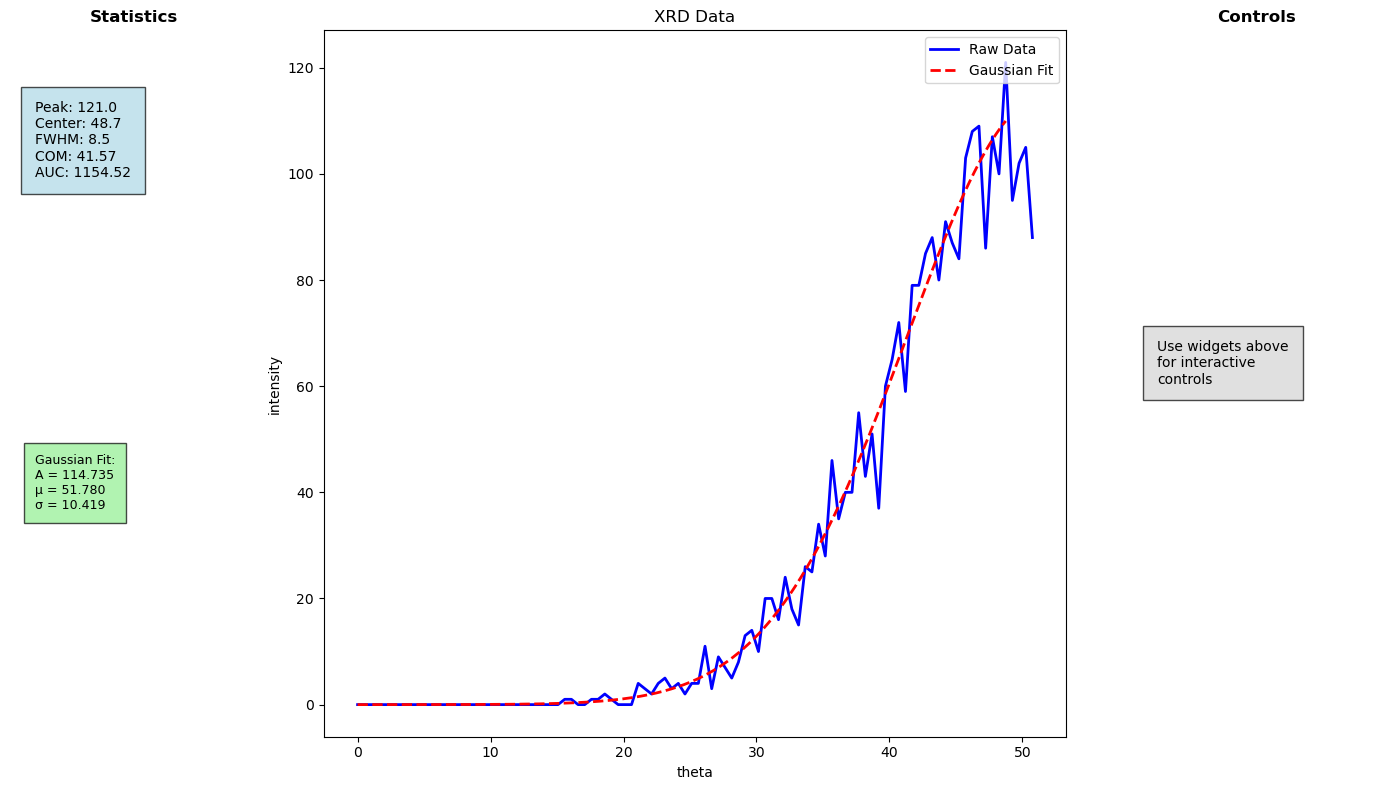

In [ ]:
%matplotlib inline
#pip install numpy matplotlib bluesky ophyd lmfit ipywidgets
from pathlib import Path
import time
from datetime import datetime
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from lmfit import Model
from bluesky import RunEngine, Msg
from bluesky.callbacks import LivePlot
import bluesky.plan_stubs as bps
from ophyd.sim import SynSignal, SynAxis
from IPython.display import Image, display, clear_output
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed

# Interval between stats panel refreshes in seconds
STATS_REFRESH_INTERVAL = 1
A, mu, sigma = 100, 50, 10  # Gaussian defaults

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)
print(f"Data directory created/confirmed: {DATA_DIR.absolute()}")

matplotlib.use('Agg')

class OverlayedLivePlot(LivePlot):
    def __init__(self, y, x):
        self.y = y
        self.x = x
        self.fit_type = 'Gaussian'
        self.detector_type = 'i0'
        self.x_data = []
        self.y_data = []
        self.dummy_motor = SynAxis(name='dummy_motor')
        self.latest_com = None
        self.latest_center = None
        self.show_fit = True

        self.fig = None
        self.ax = None
        self.line = None
        self.fit_line = None
        
        # Create widgets
        self.fit_dropdown = widgets.Dropdown(
            options=['Gaussian', 'Lorentzian', 'Pseudo-Voigt'],
            value='Gaussian',
            description='Fit Type:'
        )
        self.fit_dropdown.observe(self._on_fit_type_change, names='value')
        
        self.detector_dropdown = widgets.Dropdown(
            options=['i0', 'i1'],
            value='i0',
            description='Detector:'
        )
        self.detector_dropdown.observe(self._on_detector_change, names='value')
        
        self.fit_toggle = widgets.ToggleButton(
            value=True,
            description='Show Fit',
            button_style='success'
        )
        self.fit_toggle.observe(self._on_fit_toggle, names='value')
        
        self.move_peak_btn = widgets.Button(description="Move to Peak")
        self.move_com_btn = widgets.Button(description="Move to COM")
        self.move_peak_btn.on_click(self._move_to_peak)
        self.move_com_btn.on_click(self._move_to_com)
        
        # Display widgets
        controls = widgets.VBox([
            self.fit_dropdown,
            self.detector_dropdown, 
            self.fit_toggle,
            widgets.HBox([self.move_peak_btn, self.move_com_btn])
        ])
        display(controls)

    def _on_fit_type_change(self, change):
        self.fit_type = change['new']
        if len(self.x_data) > 10:
            self.refit_current_data()

    def _on_detector_change(self, change):
        self.detector_type = change['new']

    def _on_fit_toggle(self, change):
        self.show_fit = change['new']
        self.fit_toggle.button_style = 'success' if self.show_fit else 'danger'

    def _move_to_peak(self, button):
        if self.latest_center is not None:
            self.dummy_motor.move(self.latest_center).wait()
            print(f"Moved to peak position: {self.latest_center:.2f}")
        else:
            print("Peak position not available yet.")

    def _move_to_com(self, button):
        if self.latest_com is not None:
            self.dummy_motor.move(self.latest_com).wait()
            print(f"Moved to COM position: {self.latest_com:.2f}")
        else:
            print("COM position not available yet.")

    def _create_plot(self):
        self.fig, (self.stats_ax, self.ax, self.controls_ax) = plt.subplots(1, 3, figsize=(14, 8), 
                                                                            gridspec_kw={'width_ratios': [1, 3, 1]})
        
        # Stats panel
        self.stats_ax.axis('off')
        self.stats_ax.set_title('Statistics', fontsize=12, fontweight='bold')
        
        # Main plot
        self.ax.set_xlabel(self.x)
        self.ax.set_ylabel(self.y)
        self.ax.set_title('XRD Data')
        
        # Controls panel (just for display)
        self.controls_ax.axis('off')
        self.controls_ax.set_title('Controls', fontsize=12, fontweight='bold')
        self.controls_ax.text(0.1, 0.5, 'Use widgets above\nfor interactive\ncontrols', 
                             transform=self.controls_ax.transAxes, 
                             bbox=dict(facecolor='lightgray', alpha=0.7, pad=10))
        
        plt.tight_layout()

    def __call__(self, name, doc):
        if name == 'event':
            if self.y in doc['data'] and self.x in doc['data']:
                y_val = doc['data'][self.y]
                x_val = doc['data'][self.x]
                
                if self.fig is None:
                    self._create_plot()
                
                if self.line is None:
                    self.line, = self.ax.plot([], [], 'b-', label='Raw Data', linewidth=2)
                    self.fit_line, = self.ax.plot([], [], 'r--', label=f'{self.fit_type} Fit', linewidth=2)
                    self.ax.legend(loc='upper right')
                
                x_data = list(self.line.get_xdata())
                y_data = list(self.line.get_ydata())
                x_data.append(x_val)
                y_data.append(y_val)
                
                self.line.set_data(x_data, y_data)
                self.ax.relim()
                self.ax.autoscale_view()
                
                # Update display
                clear_output(wait=True)
                display(widgets.VBox([
                    self.fit_dropdown,
                    self.detector_dropdown, 
                    self.fit_toggle,
                    widgets.HBox([self.move_peak_btn, self.move_com_btn])
                ]))
                display(self.fig)

    def update_stats(self, peak, center, fwhm, popt=None, com=None, auc=None):
        if self.fig is None:
            return
            
        self.latest_com = com
        self.latest_center = center
        
        # Clear previous text
        self.stats_ax.clear()
        self.stats_ax.axis('off')
        self.stats_ax.set_title('Statistics', fontsize=12, fontweight='bold')
        
        # Create stats text
        stats_lines = [
            f"Peak: {peak:.1f}",
            f"Center: {center:.1f}",
            f"FWHM: {fwhm:.1f}"
        ]
        if com is not None:
            stats_lines.append(f"COM: {com:.2f}")
        if auc is not None:
            stats_lines.append(f"AUC: {auc:.2f}")
        
        stats_text = "\n".join(stats_lines)
        self.stats_ax.text(0.1, 0.9, stats_text, transform=self.stats_ax.transAxes,
                          verticalalignment='top', fontsize=10,
                          bbox=dict(facecolor='lightblue', alpha=0.7, pad=10))
        
        if popt is not None and self.show_fit:
            labels = ['A', 'μ', 'σ'] if self.fit_type == 'Gaussian' else ['A', 'x₀', 'γ']
            if self.fit_type == 'Pseudo-Voigt':
                labels = ['A', 'x₀', 'σ', 'γ', 'η']
            
            param_lines = [f"{k} = {v:.3f}" for k, v in zip(labels, popt)]
            param_text = f"{self.fit_type} Fit:\n" + "\n".join(param_lines)
            
            self.stats_ax.text(0.1, 0.4, param_text, transform=self.stats_ax.transAxes,
                              verticalalignment='top', fontsize=9,
                              bbox=dict(facecolor='lightgreen', alpha=0.7, pad=8))

    def refit_current_data(self):
        if len(self.x_data) > 10 and len(self.x_data) == len(self.y_data):
            calculate_stats(self, self.x_data, self.y_data)

def gaussian(x, a=1, mu=0, sigma=1):
    return a * np.exp(-((x - mu)**2) / (2 * sigma**2))

def lorentzian(x, a=1, x0=0, gamma=1):
    return a * (gamma**2) / ((x - x0)**2 + gamma**2)

def pseudo_voigt(x, a=1, x0=0, sigma=1, gamma=1, eta=0.5):
    g = np.exp(-((x - x0)**2) / (2 * sigma**2))
    l = (gamma**2) / ((x - x0)**2 + gamma**2)
    return a * ((1 - eta) * g + eta * l)

def gaussian_data_generator():
    x_range = np.linspace(0, 100, 200)
    for x in x_range:
        dummy_signal = gaussian(x, A, mu, sigma)
        noisy_signal = np.random.poisson(dummy_signal)
        yield x, noisy_signal

def calculate_stats(plot, x, y):
    x, y = np.array(x), np.array(y)
    if len(x) < 10 or len(x) != len(y): 
        return
    sort_idx = np.argsort(x)
    x, y = x[sort_idx], y[sort_idx]
    peak = np.max(y)
    center = x[np.argmax(y)]
    com = np.sum(x * y) / np.sum(y)
    auc = np.trapezoid(y, x)
    
    popt = None
    try:
        if plot.fit_type == 'Gaussian':
            model = Model(gaussian)
            params = model.make_params(a=peak, mu=center, sigma=sigma)
        elif plot.fit_type == 'Lorentzian':
            model = Model(lorentzian)
            params = model.make_params(a=peak, x0=center, gamma=sigma)
        elif plot.fit_type == 'Pseudo-Voigt':
            model = Model(pseudo_voigt)
            params = model.make_params(a=peak, x0=center, sigma=sigma, gamma=sigma, eta=0.5)
            params['eta'].min, params['eta'].max = 0, 1
        
        fit_result = model.fit(y, params, x=x)
        x_fit = np.linspace(x.min(), x.max(), 500)
        y_fit = model.eval(fit_result.params, x=x_fit)
        
        if plot.show_fit and plot.fit_line is not None:
            plot.fit_line.set_data(x_fit, y_fit)
            plot.fit_line.set_visible(True)
            plot.fit_line.set_label(f'{plot.fit_type} Fit')
        elif plot.fit_line is not None:
            plot.fit_line.set_visible(False)
            
        plot.ax.legend(loc='upper right')
        popt = list(fit_result.best_values.values())
        
    except Exception as e:
        print(f"Fit failed: {e}")
        if plot.fit_line is not None:
            plot.fit_line.set_visible(False)
    
    half_max = peak / 2
    indices = np.where(y >= half_max)[0]
    fwhm = float('nan') if len(indices) < 2 else x[indices[-1]] - x[indices[0]]
    
    plot.update_stats(peak, center, fwhm, popt, com, auc)

def stream(plot):
    global last_analysis_time
    yield Msg('open_run')
    try:
        for x, y in data_gen:
            intensity_signal.put(y)
            theta_signal.put(x)
            x_vals.append(x)
            y_vals.append(y)
            plot.x_data = x_vals
            plot.y_data = y_vals
            yield Msg('create', name='primary')
            yield Msg('read', intensity_signal)
            yield Msg('read', theta_signal)
            yield Msg('save')
            if time.time() - last_analysis_time >= STATS_REFRESH_INTERVAL:
                calculate_stats(plot, x_vals, y_vals)
                last_analysis_time = time.time()
            yield from bps.sleep(0.05)
    finally:
        yield Msg('close_run')

# --- Execution setup ---
last_analysis_time = time.time()
x_vals, y_vals = [], []
data_gen = gaussian_data_generator()
intensity_signal = SynSignal(name='intensity', func=lambda: 0)
theta_signal = SynSignal(name='theta', func=lambda: 0)

plot = OverlayedLivePlot('intensity', 'theta')
RE = RunEngine({})
RE.subscribe(plot)

RE(stream(plot))

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
data_filename = DATA_DIR / f'xrd_raw_data_{timestamp}.csv'
plot_filename = DATA_DIR / f'xrd_plot_{timestamp}.png'

np.savetxt(data_filename, np.column_stack((x_vals, y_vals)), delimiter=',', header='theta,intensity', comments='')
print(f'Saved data to {data_filename}')

if plot.fig is not None:
    plot.fig.savefig(plot_filename, dpi=150, bbox_inches='tight')
    print(f'Saved plot to {plot_filename}')

plt.close('all')

0.0068115234375000005

NameError: name 'RE' is not defined